# Niterói Census 2022: Dataset Characterization Baseline
 This notebook provides an overview of the 2022 IBGE Census data for Niterói, RJ, Brazil.
 It demonstrates how to load the geospatial layers and merge them with demographic and infrastructure indicators.

In [72]:
# %%
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify

In [ ]:
# Configuration
DATA_DIR = "../data/ibge_census_data_2022"
GPKG_PATH = os.path.join(DATA_DIR, "niteroi_census_borders.gpkg")

# 1. Loading and Verifying Geospatial Layers
 Let's inspect the spatial layers available inside our GeoPackage.

In [74]:
# Load the primary census tract layer (adjust layer name based on your GPKG structure)
# Usually, it's the first layer or named something like 'setores_censitarios'
tracts_gdf = gpd.read_file(GPKG_PATH, layer=1)

print(f"\nLoaded {len(tracts_gdf)} census tracts.")
print(f"Current CRS: {tracts_gdf.crs}")

# Ideal CRS for accurate metric calculations in Rio de Janeiro: SIRGAS 2000 / UTM zone 23S
if tracts_gdf.crs != "EPSG:31983":
    tracts_gdf = tracts_gdf.to_crs(epsg=31983)
    print("Projected coordinate system standardized to EPSG:31983 (SIRGAS 2000 / UTM 23S)")


Loaded 1289 census tracts.
Current CRS: EPSG:4674
Projected coordinate system standardized to EPSG:31983 (SIRGAS 2000 / UTM 23S)


# 2. Integrating Tabular Indicators
 We will read the translated dictionary to see our metrics, load the population dataset, and join it directly to our geospatial tracks using the common geographic ID identifier.

In [75]:
# %%
# Load the Census Tracts Data Dictionary
dict_path = os.path.join(DATA_DIR, "census_tracts_indicators", "dict_census_tracts_2022.csv")
tract_dict = pd.read_csv(dict_path, sep=';')

print("Sample of translated metadata dictionary:")
print(tract_dict.head())

# Load Population Indicators
# Force pandas to split the columns by the semicolon delimiter
pop_path = os.path.join(DATA_DIR, "census_tracts_indicators", "population_indicators_2022.csv")
pop_df = pd.read_csv(pop_path, sep=';')

# Normalize and strip hidden spaces from headers
tracts_gdf.columns = tracts_gdf.columns.str.strip()
pop_df.columns = pop_df.columns.str.strip()

# Dynamically resolve column keys (Handling casing safely)
spatial_id_col = "CD_SETOR" if "CD_SETOR" in tracts_gdf.columns else "cd_setor"
tabular_id_col = "CD_SETOR" if "CD_SETOR" in pop_df.columns else "cd_setor"

# Cast keys to string and merge
tracts_gdf[spatial_id_col] = tracts_gdf[spatial_id_col].astype(str)
pop_df[tabular_id_col] = pop_df[tabular_id_col].astype(str)

merged_gdf = tracts_gdf.merge(
    pop_df, 
    left_on=spatial_id_col, 
    right_on=tabular_id_col, 
    how='inner'
)

print(f"Success! Merged dataset contains {len(merged_gdf)} active census tracts.")
print("Merged columns:", list(merged_gdf.columns[:5]))

Sample of translated metadata dictionary:
        theme         indicator                                  description
0     General          cd_setor                           Census sector code
1  Population         pop_total                    Total resident population
2  Population   pop_total_homem               Total male resident population
3  Population  pop_total_mulher             Total female resident population
4  Population    idade_0_4_anos  Total resident population aged 0 to 4 years
Success! Merged dataset contains 1289 active census tracts.
Merged columns: ['id', 'CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO']


# 4. Exploratory Spatial Analysis & Mapping
 Now that the datasets are merged, we can investigate the demographic landscape of Niterói.
 Let's compute global aggregates and map the population distribution.

Characterization Summary for Niterói (2022 Census):
 - Total Mapped Population: 484,991
 - Average Population per Census Tract: 376.3


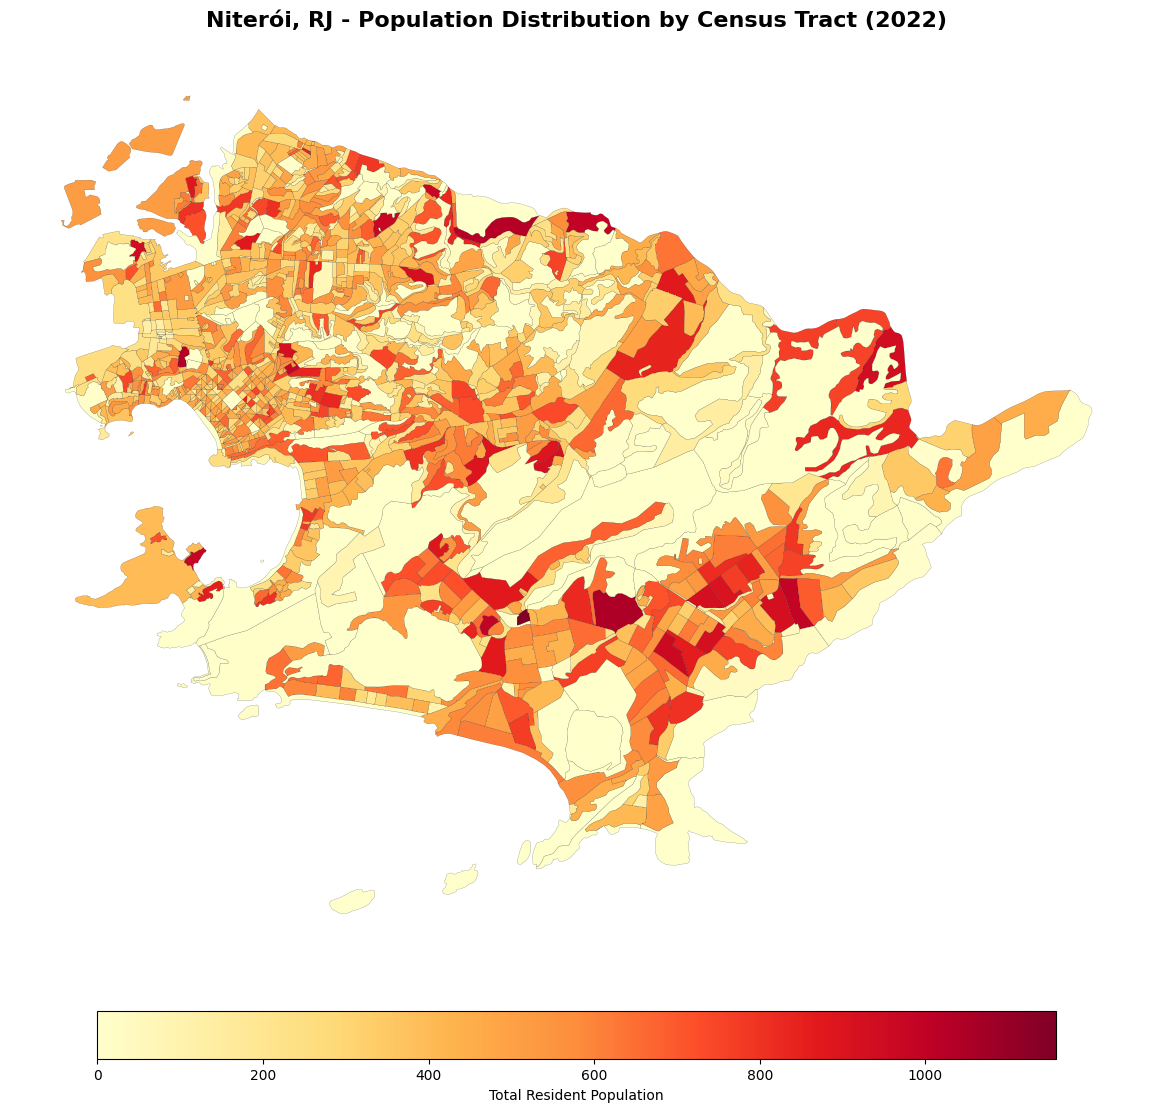

In [76]:
# Calculate general baseline characteristics
total_population = merged_gdf['pop_total'].sum()
average_tract_pop = merged_gdf['pop_total'].mean()

print(f"Characterization Summary for Niterói (2022 Census):")
print(f" - Total Mapped Population: {total_population:,}")
print(f" - Average Population per Census Tract: {average_tract_pop:.1f}")

# Plotting a clean Choropleth Map of Population Density / Distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot the census tracts using a colormap
merged_gdf.plot(
    column='pop_total',
    cmap='YlOrRd',  # Yellow-Orange-Red gradient is great for density
    legend=True,
    legend_kwds={
        'label': "Total Resident Population",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.7
    },
    ax=ax,
    edgecolor='black',
    linewidth=0.1   # Keep boundaries thin so the map looks crisp
)

# Style adjustments
ax.set_title("Niterói, RJ - Population Distribution by Census Tract (2022)", fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()  # Turn off lat/lon grid lines for a clean presentation

plt.tight_layout()
plt.show()

# 5. Analyzing Favela and Urban Community Context
# IBGE categorizes census tracts by their operational characteristics. Let's inspect the sector type attribute (`CD_TIPO`) to identify formal urban areas versus Favelas and Urban Communities. Typically, IBGE uses `CD_TIPO = '1'` (or simply `1` depending on formatting) to represent these communities.

In [77]:
# Define the official 2022 IBGE sector type mapping
sector_type_translation = {
    1: "Favela or Urban Community (Favela ou comunidade urbana)",
    2: "Barracks or Military Base (Quartel ou base militar)",
    3: "Lodging or Camp (Alojamento ou acampamento)",
    4: "Low Household Density Area (Baixo patamar domiciliar)",
    5: "Indigenous Settlement (Agrupamento indígena)",
    6: "Prison Unit (Unidade prisional)",
    7: "Institutional Care / Convent / Hospital (Convento, hospital, ILPI, etc.)",
    8: "Settlement Project Agrovila (Agrovila de Projeto de Assentamento)",
    9: "Quilombola Settlement (Agrupamento quilombola)"
}

# 2. Ensure the column is read consistently as an integer for direct dictionary matching
# Note: Check if your spatial file column is named 'TIPO' or 'CD_TIPO' based on your previous printout
type_col = 'CD_TIPO' if 'CD_TIPO' in merged_gdf.columns else 'TIPO'
merged_gdf[type_col] = pd.to_numeric(merged_gdf[type_col], errors='coerce')

# Print the distribution with clean English labels for your challenge participants
print("Census Tract Types Distribution in Niterói (2022):")
type_counts = merged_gdf[type_col].value_counts()
for code, count in type_counts.items():
    label = sector_type_translation.get(code, f"Other/Standard Urban Fabric (Code {code})")
    print(f" - Code {code} | {label}: {count} tracts")

# 3. Create a clean boolean flag isolating Favelas using Code 1
merged_gdf['is_favela'] = merged_gdf[type_col] == 1

# 4. Calculate baseline spatial distribution metrics
total_population = merged_gdf['pop_total'].sum()
favela_pop = merged_gdf[merged_gdf['is_favela']]['pop_total'].sum()
formal_pop = merged_gdf[~merged_gdf['is_favela']]['pop_total'].sum()
favela_tract_count = merged_gdf['is_favela'].sum()

print(f"\nSocio-Spatial Population Breakdown:")
print(f" - Total Favela Tracts: {favela_tract_count} out of {len(merged_gdf)} total tracts")
print(f" - Population residing in Favelas: {favela_pop:,} ({(favela_pop/total_population)*100:.1f}%)")
print(f" - Population residing in Formal/Other Areas: {formal_pop:,} ({(formal_pop/total_population)*100:.1f}%)")

Census Tract Types Distribution in Niterói (2022):
 - Code 0 | Other/Standard Urban Fabric (Code 0): 963 tracts
 - Code 1 | Favela or Urban Community (Favela ou comunidade urbana): 209 tracts
 - Code 4 | Low Household Density Area (Baixo patamar domiciliar): 107 tracts
 - Code 7 | Institutional Care / Convent / Hospital (Convento, hospital, ILPI, etc.): 5 tracts
 - Code 6 | Prison Unit (Unidade prisional): 4 tracts
 - Code 9 | Quilombola Settlement (Agrupamento quilombola): 1 tracts

Socio-Spatial Population Breakdown:
 - Total Favela Tracts: 209 out of 1289 total tracts
 - Population residing in Favelas: 86,983 (17.9%)
 - Population residing in Formal/Other Areas: 398,008 (82.1%)


# Mapping the Spatial Contrast
# Let's visualize where these communities sit geographically within the broader municipal borders of Niterói.

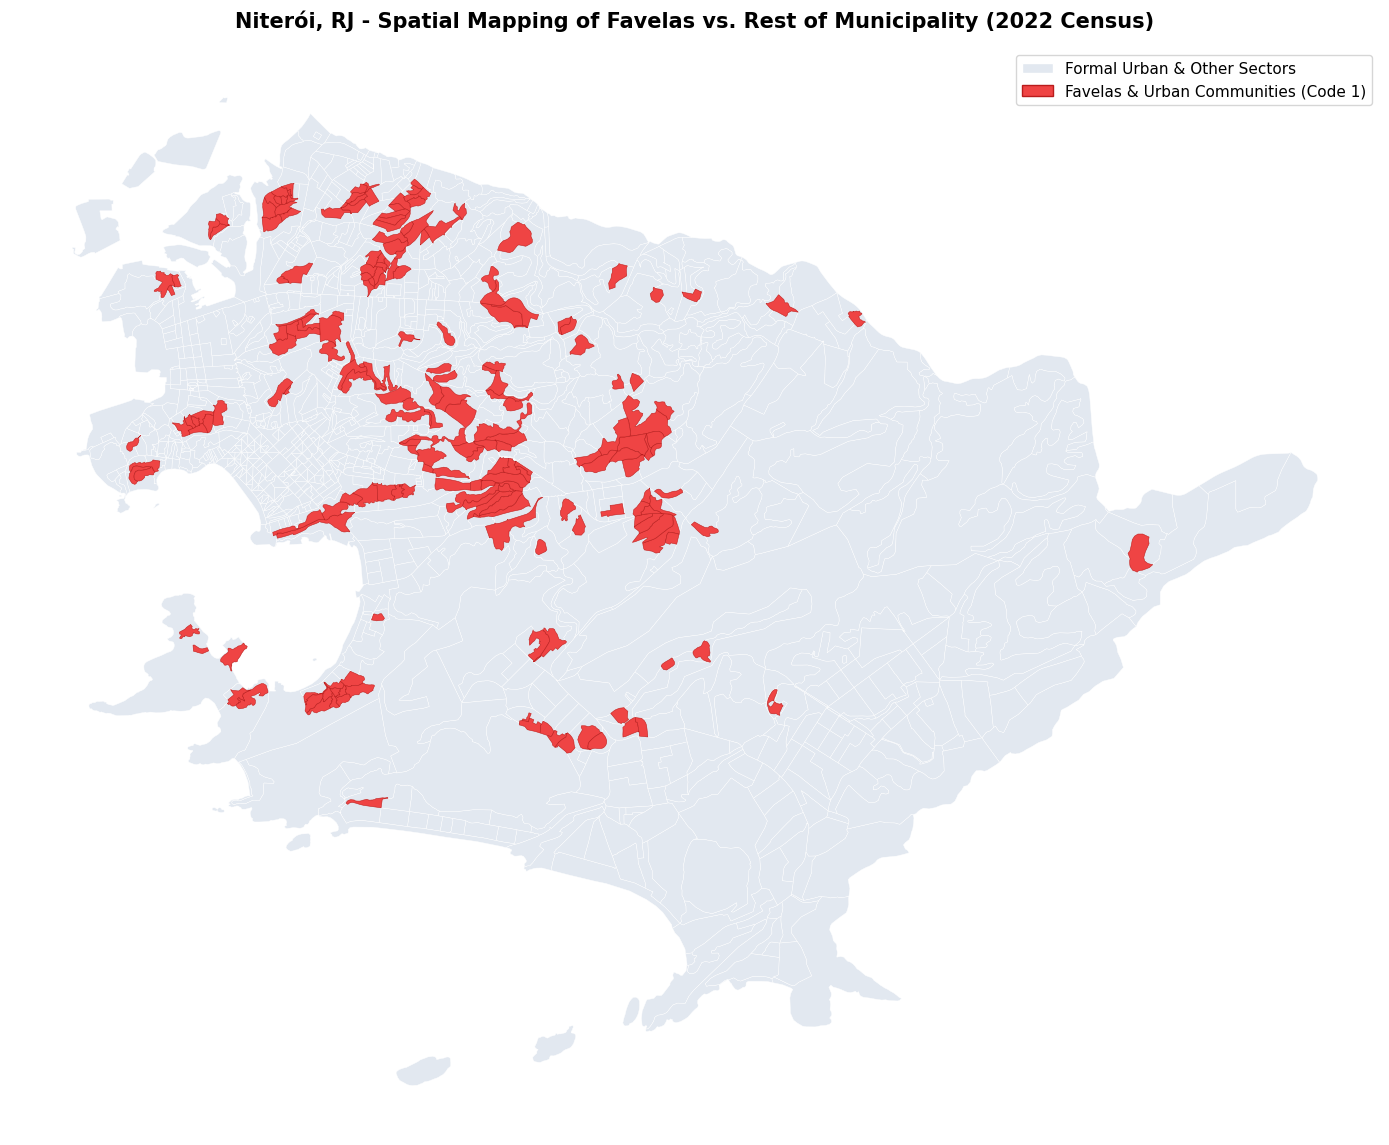

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot formal fabric and other sectors in a clean, neutral slate grey
merged_gdf[~merged_gdf['is_favela']].plot(
    ax=ax,
    color='#e2e8f0',
    edgecolor='#ffffff',
    linewidth=0.3
)

# Overlay Favela communities (Code 1) in a high-contrast Crimson
merged_gdf[merged_gdf['is_favela']].plot(
    ax=ax,
    color='#ef4444',
    edgecolor='#b91c1c',
    linewidth=0.4
)

# Custom plot presentation styling
ax.set_title("Niterói, RJ - Spatial Mapping of Favelas vs. Rest of Municipality (2022 Census)", fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()

# Build a explicit custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e2e8f0', edgecolor='#ffffff', label='Formal Urban & Other Sectors'),
    Patch(facecolor='#ef4444', edgecolor='#b91c1c', label='Favelas & Urban Communities (Code 1)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Similar visualization from GPKG file to confirm CD_TIPO

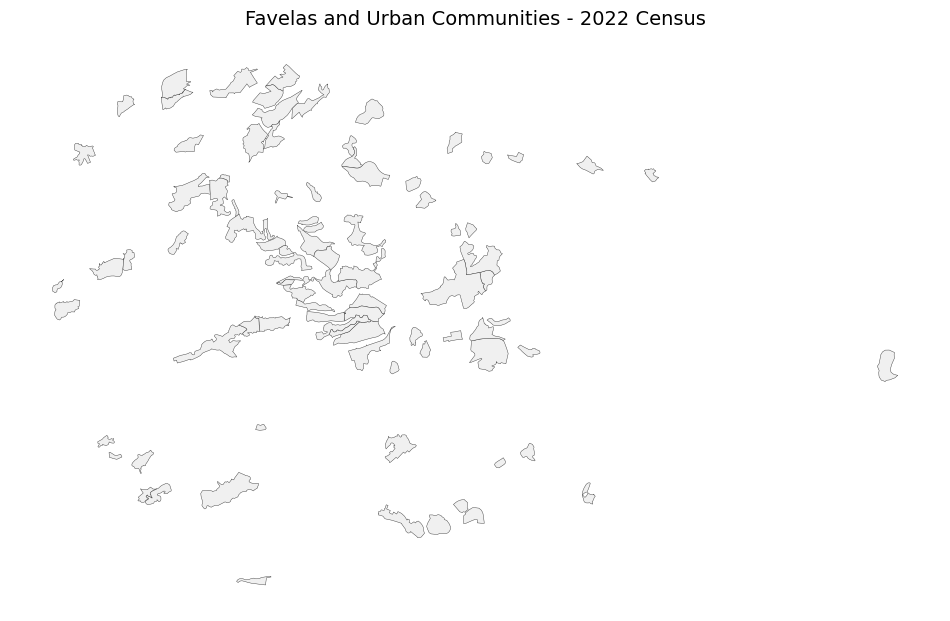

In [79]:
# Read a specific layer (replace layer name with your actual target layer)
favelas_gdf = gpd.read_file(GPKG_PATH, layer="favelas_e_comunidades_censo2022", engine="pyogrio")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))
favelas_gdf.plot(
    ax=ax, 
    color="#f0f0f0",     # Fill color for polygons
    edgecolor="#333333", # Boundary line color
    linewidth=0.3        # Border thickness
)

# Clean up aesthetics
ax.set_title("Favelas and Urban Communities - 2022 Census", fontsize=14, pad=10)
ax.axis("off")  # Removes latitude/longitude grid lines for a cleaner look

plt.show()

# 5. Choropleth Mapping: Income Distribution in Niterói
 We explicitly load the household heads dataset, merge it using our adaptive keys, sanitize the data formats, and generate a robust quantile choropleth map.

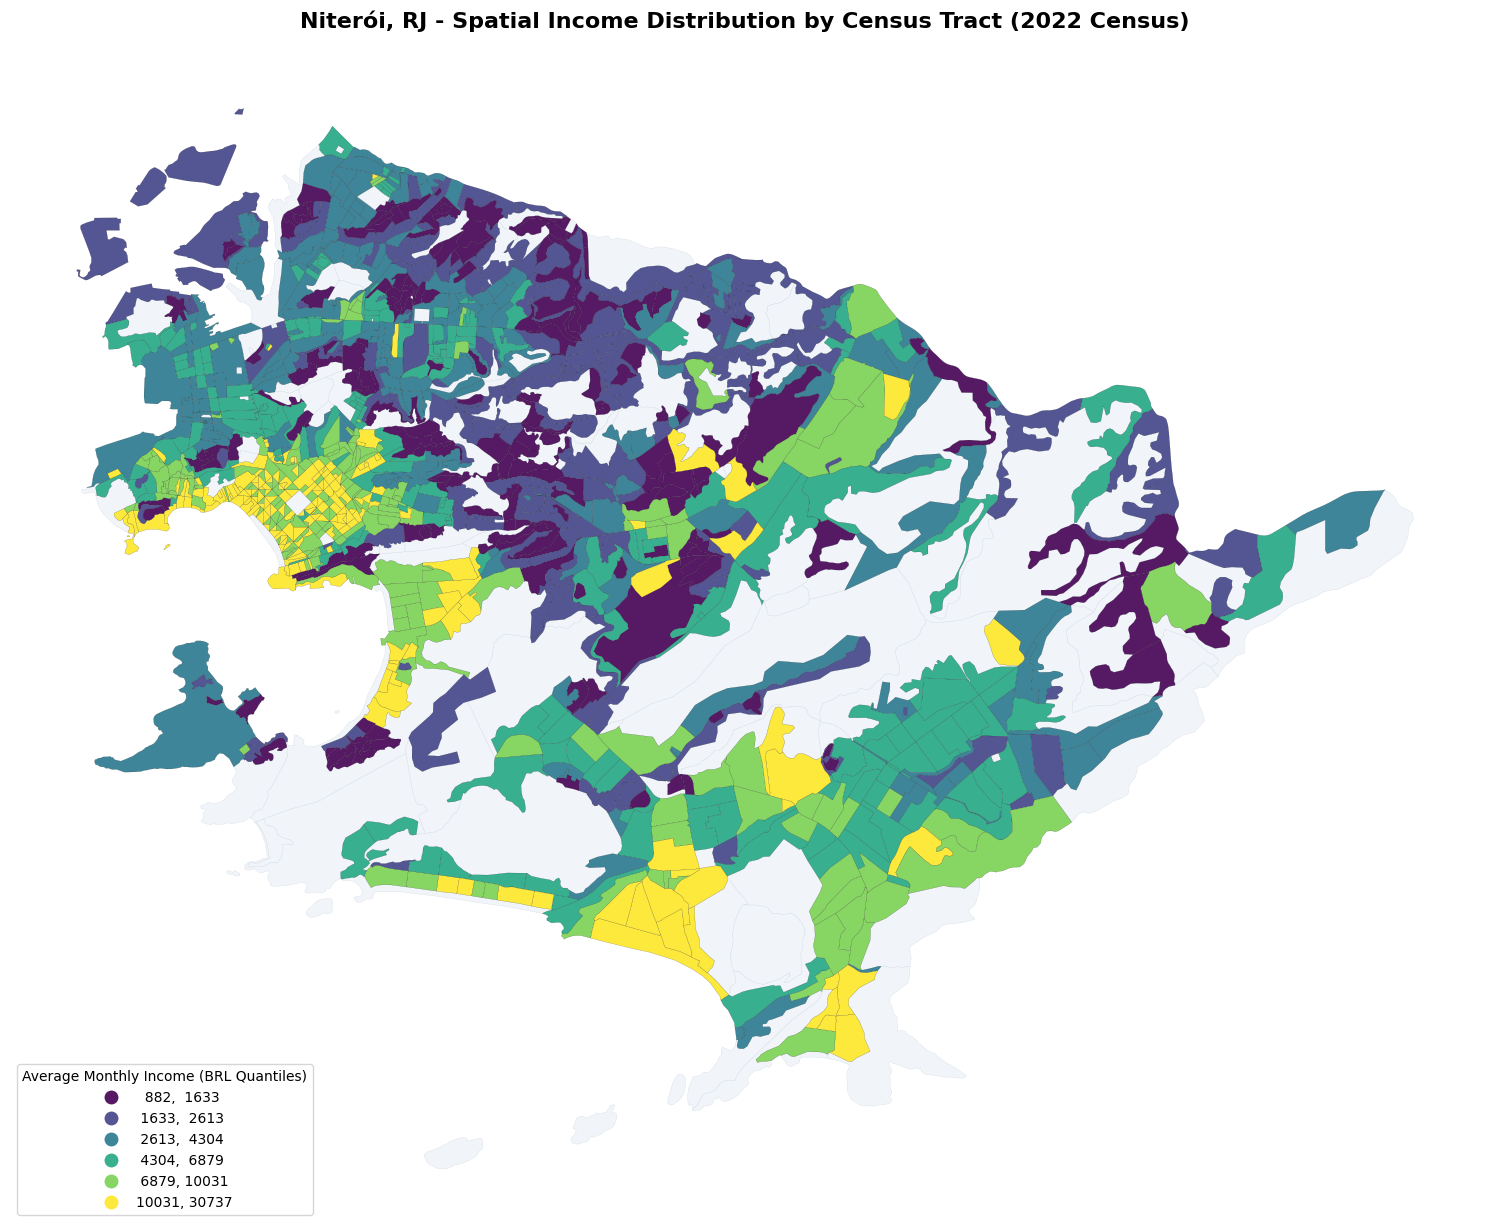

In [80]:
# Load the household heads indicators file explicitly passing the semicolon separator
heads_path = os.path.join(DATA_DIR, "census_tracts_indicators", "household_heads_indicators_2022.csv")
heads_df = pd.read_csv(heads_path, sep=';')
heads_df.columns = heads_df.columns.str.strip()

# Resolve and cast the join key for the incoming table
heads_id_col = "CD_SETOR" if "CD_SETOR" in heads_df.columns else "cd_setor"
heads_df[heads_id_col] = heads_df[heads_id_col].astype(str)

# Squeeze down columns to isolate target features and prevent overlap/suffix conflicts
columns_to_keep = ['resp_rendimento_medio', 'resp_rendimento_variancia']
heads_sliced = heads_df[[heads_id_col] + [col for col in columns_to_keep if col in heads_df.columns]].copy()

# Perform the clean inner merge
merged_gdf = merged_gdf.merge(
    heads_sliced, 
    left_on=spatial_id_col, 
    right_on=heads_id_col, 
    how='inner',
    suffixes=('', '_new')
)

# If an overlapping column was created by pandas, prioritize the fresh incoming one
if 'resp_rendimento_medio_new' in merged_gdf.columns:
    merged_gdf['resp_rendimento_medio'] = merged_gdf['resp_rendimento_medio_new']
    merged_gdf.drop(columns=['resp_rendimento_medio_new'], inplace=True)

# Aggressive Numeric Cleaning directly inside the final working dataframe
# Replace Brazilian commas with dots, strip text artifacts, and coerce errors to NaN
merged_gdf['resp_rendimento_medio'] = (
    merged_gdf['resp_rendimento_medio']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
merged_gdf['resp_rendimento_medio'] = pd.to_numeric(merged_gdf['resp_rendimento_medio'], errors='coerce')

# Separate mapped elements to deal with extreme outliers and unoccupied spaces cleanly
valid_income_mask = (merged_gdf['resp_rendimento_medio'] > 0) & (merged_gdf['resp_rendimento_medio'].notna())

# Setup the plotting canvas
fig, ax = plt.subplots(1, 1, figsize=(15, 13))

# Plot unoccupied/missing-income tracts in a subtle, neutral light background pattern
merged_gdf[~valid_income_mask].plot(
    ax=ax,
    color='#f1f5f9',
    edgecolor='#cbd5e1',
    linewidth=0.2,
    label='No Data / Unoccupied'
)

# Plot the Choropleth Layer using an eloquent sequential color map
# We use robust quantiles (Mapclassify required) to handle Niterói's massive wealth skew
merged_gdf[valid_income_mask].plot(
    column='resp_rendimento_medio',
    cmap='viridis',
    scheme='Quantiles', 
    k=6,
    legend=True,
    legend_kwds={
        'title': "Average Monthly Income (BRL Quantiles)",
        'loc': 'lower left',
        'fmt': "{:.0f}",
        'frameon': True,
        'fontsize': 10
    },
    ax=ax,
    edgecolor='black',
    linewidth=0.1,
    alpha=0.9
)

# Canvas styling refinements
ax.set_title("Niterói, RJ - Spatial Income Distribution by Census Tract (2022 Census)", fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()